## **Libraries** 

In [ ]:
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import plotly.express as px
from ultralytics import YOLO
from roboflow import Roboflow
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
import plotly.io as pio
pio.renderers.default = "svg"

## **Download Roboflow Dataset**

In [ ]:
rf = Roboflow(api_key="t*****************lq")
project = rf.workspace("my-workspace-tlolv").project("road-damage-l1ju7-sqdr6")
version = project.version(2)
dataset = version.download("yolov8")

print("Downloaded Successfully")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-damage-2 in yolov8:: 100%|██████████| 13518/13518 [00:05<00:00, 2660.68it/s]


Downloaded Successfully


## **Paths & Variables**

In [5]:
img_paths = random.sample(list(Path(f"{dataset.location}/train/images").iterdir()), 9)
data = f"{dataset.location}/data.yaml"
epochs = 80
img_size = 640
batch_size = 16
learning_rate = 0.01
optimizer = "auto"
seed = 42
output = f"{dataset.location}/output"

## **Data Exploration**

100%|██████████| 9/9 [00:00<00:00, 28.32it/s]


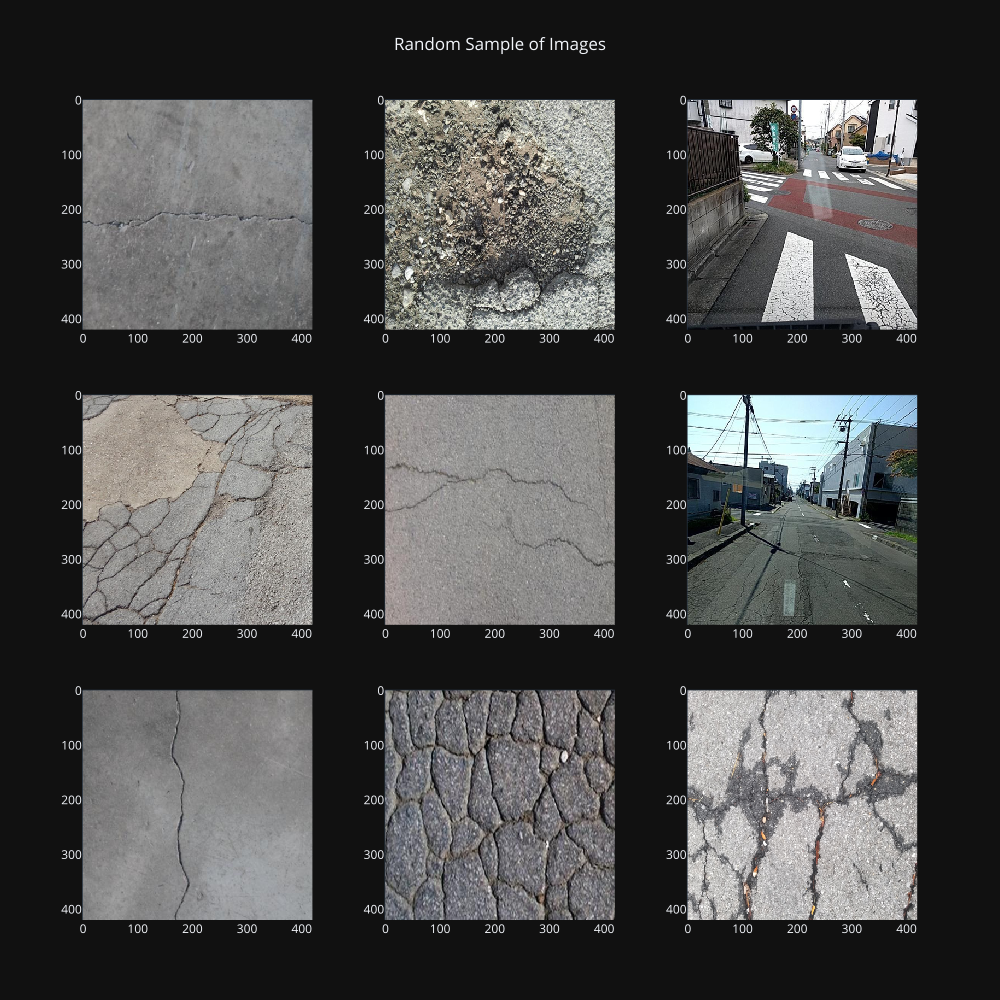

In [6]:
fig = make_subplots(rows= 3,
                    cols= 3,
                    horizontal_spacing= 0.08,
                    vertical_spacing= 0.08)

rows, cols = 1, 1
for image in tqdm(img_paths):
    img = np.array(Image.open(image).resize((420,420)))

    fig.add_trace(go.Image(z=img),
                  row= rows,
                  col= cols)

    cols += 1
    if cols > 3:
        rows += 1
        cols = 1

fig.update_layout(title="Random Sample of Images",
                  title_x=0.5,
                  template="plotly_dark",
                  width=1000,
                  height=1000,
                  showlegend=False)

fig.show()

## **Training**

In [7]:
def training(model_name):
    print(f"Training {model_name}...\n")

    model = YOLO(model_name + ".pt")

    model.train(data= data,
                epochs= epochs,
                imgsz= img_size,
                batch= batch_size,
                lr0= learning_rate,
                optimizer= optimizer,
                project= output,
                name= model_name,
                exist_ok= True,
                seed= seed,
                patience= 10)

    print(f"Training {model_name} is done.")

#### **1. YOLOv8n**

In [8]:
training("yolov8n")

Training yolov8n...

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/road-damage-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

#### **2. YOLOv8s**

In [9]:
training("yolov8s")

Training yolov8s...

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/road-damage-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

#### **3. YOLOv8m**

In [10]:
training("yolov8m")

Training yolov8m...

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/road-damage-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

## **Evaluation**

In [ ]:
output_csv = f"{dataset.location}/output/yolo.csv"

models = {
    "YOLOv8n" : f"{dataset.location}/output/yolov8n/weights/best.pt",
    "YOLOv8s" : f"{dataset.location}/output/yolov8s/weights/best.pt",
    "YOLOv8m" : f"{dataset.location}/output/yolov8m/weights/best.pt"
}

def eval(name, weight):
    print(f"Evaluating {name}...")

    model = YOLO(weight)
    metrics = model.val(data= data,
                       imgsz= img_size,
                       verbose= False)

    size = Path(weight).stat().st_size / (1024 * 1024)
    fps = round(1000 / metrics.speed["inference"], 1)

    return {
        "Model" : name,
        "mAP50" : round(metrics.box.map50, 4),
        "mAP50-95" : round(metrics.box.map, 4),
        "Precision" : round(metrics.box.mp, 4),
        "Recall" : round(metrics.box.mr, 4),
        "FPS" : fps,
        "Size_MB" : size
    }

In [14]:
results = []

for name, weight in models.items():
    results.append(eval(name, weight))

df = pd.DataFrame(results)
df.to_csv(output_csv, index= False)
df

Evaluating YOLOv8n...
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1006.5±913.8 MB/s, size: 76.6 KB)
val: Scanning /kaggle/working/road-damage-2/valid/labels.cache... 1146 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1146/1146 437.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 33, len(boxes) = 3588. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 3.9it/s 18.3s0.2ss
                   all       1146       3588       0.58      0.422      0.409      0.239
Speed: 0.9ms preprocess, 4.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Resul

,Model,mAP50,mAP50-95,Precision,Recall,FPS,Size
0,YOLOv8n,0.4086,0.2389,0.5801,0.4221,227.0,5.953531
1,YOLOv8s,0.4315,0.2489,0.6204,0.4423,121.8,21.470743
2,YOLOv8m,0.4268,0.2469,0.5989,0.4464,51.8,49.616716


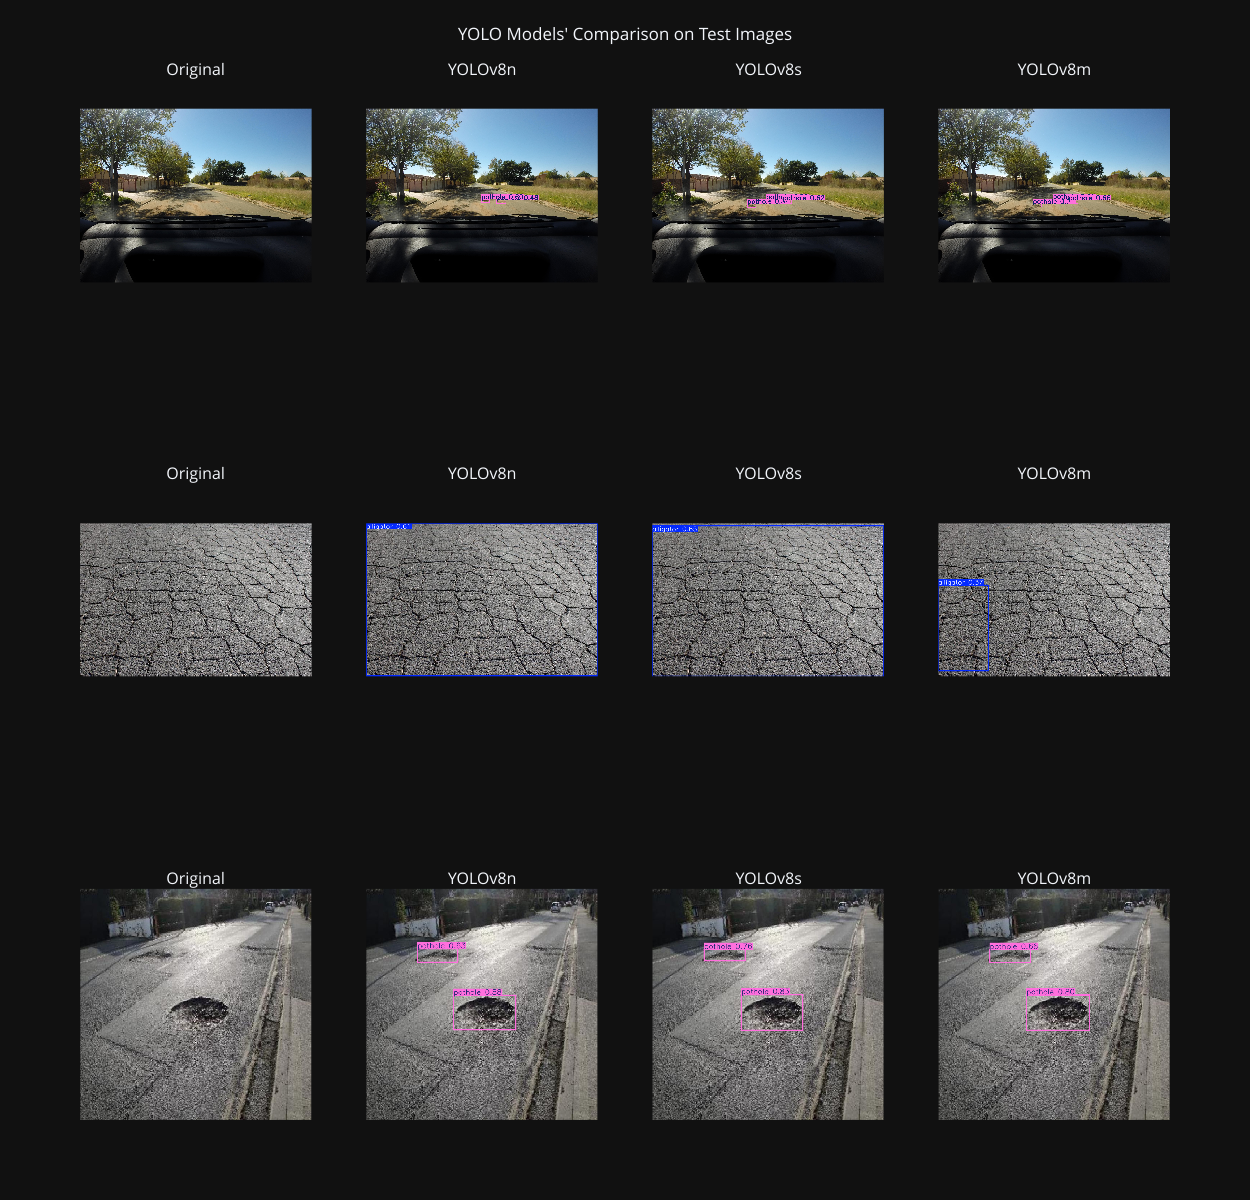

In [39]:
test_imgs = random.sample(list(Path(f"{dataset.location}/test/images").iterdir()), 3)

loaded_models = {
    name: YOLO(weight)
    for name, weight in models.items()
}

fig2 = make_subplots(rows= 3,
                    cols= 4,
                    subplot_titles= [title for i in range(4) 
                                     for title in ["Original", "YOLOv8n", "YOLOv8s", "YOLOv8m"]])

for rows, image in enumerate(test_imgs, start= 1):
    original= Image.open(image)

    fig2.add_trace(
        go.Image(z= original),
        row= rows,
        col= 1
    )

    for cols, (name, model) in enumerate(loaded_models.items(), start= 2):
        result = model.predict(
            str(image),
            conf= 0.25,
            verbose= False
        )[0]

        pred_res = cv2.cvtColor(
            result.plot(),
            cv2.COLOR_BGR2RGB
        )

        fig2.add_trace(
            go.Image(z= pred_res),
            row= rows,
            col= cols
        )


fig2.update_xaxes(showticklabels=False, visible=False)
fig2.update_yaxes(showticklabels=False, visible=False)

fig2.update_layout(
    template="plotly_dark",
    height=1200,
    width=1250,
    title="YOLO Models' Comparison on Test Images",
    title_x=0.5,
    margin=dict(t=80)
)

fig2.show()

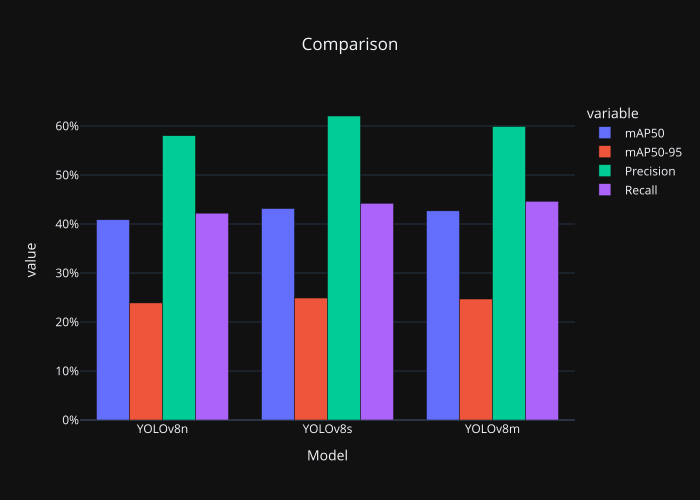

In [48]:
fig3 = px.bar(df,
             x= "Model",
             y= ["mAP50", "mAP50-95", "Precision", "Recall"],
             title= "Comparison",
             barmode= "group",
             template= "plotly_dark")

fig3.update_yaxes(tickformat=".0%")
fig3.update_layout(title_x=0.5)
fig3.show()

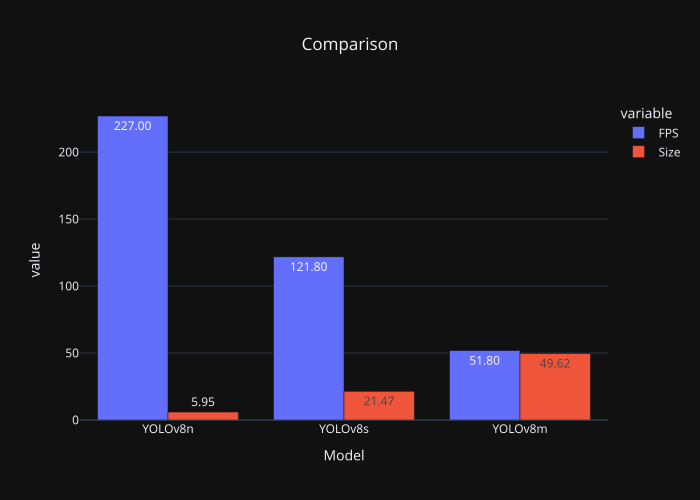

In [51]:
fig3 = px.bar(df,
             x= "Model",
             y= ["FPS", "Size"],
             title= "Comparison",
             barmode= "group",
             text_auto= ".2f",
             template= "plotly_dark")

fig3.update_layout(title_x=0.5)
fig3.show()

## **Model Evaluation Report**

### **Three YOLOv8 models (YOLOv8n, YOLOv8s, and YOLOv8m) were evaluated using mAP, precision, recall, inference speed (FPS), and model size. Among the tested models, YOLOv8s achieved the best overall detection performance, recording the highest mAP50 (0.4315), mAP50-95 (0.2489), and precision (0.6204). Although YOLOv8m achieved the highest recall (0.4464), its lower FPS (51.8) and significantly larger model size (49.62 MB) make it less suitable for real-time applications. In contrast, YOLOv8n delivered the fastest inference speed (227 FPS) and the smallest model size (5.95 MB), making it ideal for resource-constrained environments despite its lower detection accuracy. Overall, YOLOv8s provides the best balance between detection performance, inference speed, and model size, making it the most suitable model for deployment in this project.**